In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
_data = pd.read_csv('Офіційний курс гривні щодо іноземних валют.csv')
_data.head(10)

,Дата,Час,Код цифровий,Код літерний,Кількість одиниць,Назва валюти,"Офіційний курс гривні, грн"
0,01.01.2022,0.0,840,USD,1,Долар США,27.2782
1,02.01.2022,0.0,840,USD,1,Долар США,27.2782
2,03.01.2022,0.0,840,USD,1,Долар США,27.2782
3,04.01.2022,0.0,840,USD,1,Долар США,27.2782
4,05.01.2022,0.0,840,USD,1,Долар США,27.2976
5,06.01.2022,0.0,840,USD,1,Долар США,27.4551
6,07.01.2022,0.0,840,USD,1,Долар США,27.4551
7,08.01.2022,0.0,840,USD,1,Долар США,27.4551
8,09.01.2022,0.0,840,USD,1,Долар США,27.4551
9,10.01.2022,0.0,840,USD,1,Долар США,27.4977


In [6]:
_data[['Дата', 'Офіційний курс гривні, грн']].head(10)

,Дата,"Офіційний курс гривні, грн"
0,01.01.2022,27.2782
1,02.01.2022,27.2782
2,03.01.2022,27.2782
3,04.01.2022,27.2782
4,05.01.2022,27.2976
5,06.01.2022,27.4551
6,07.01.2022,27.4551
7,08.01.2022,27.4551
8,09.01.2022,27.4551
9,10.01.2022,27.4977


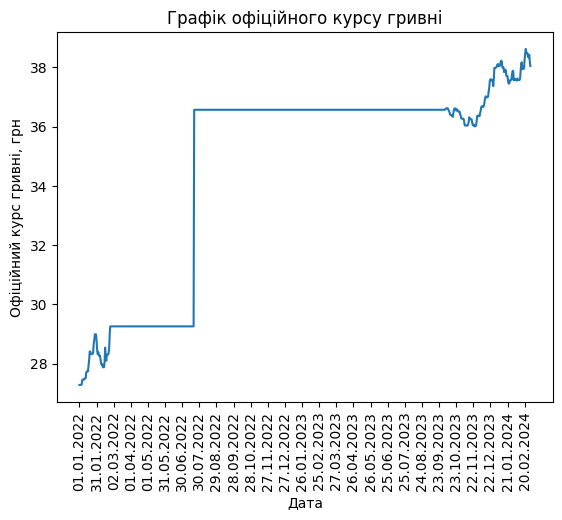

In [8]:
date = _data['Дата'].to_numpy()
value = _data['Офіційний курс гривні, грн'].to_numpy()

plt.plot(figsize=(12, 6))
plt.plot(date, value)
plt.xlabel('Дата')
plt.ylabel('Офіційний курс гривні, грн')
plt.title('Графік офіційного курсу гривні')
plt.xticks(date[::30], rotation=90)
plt.show()


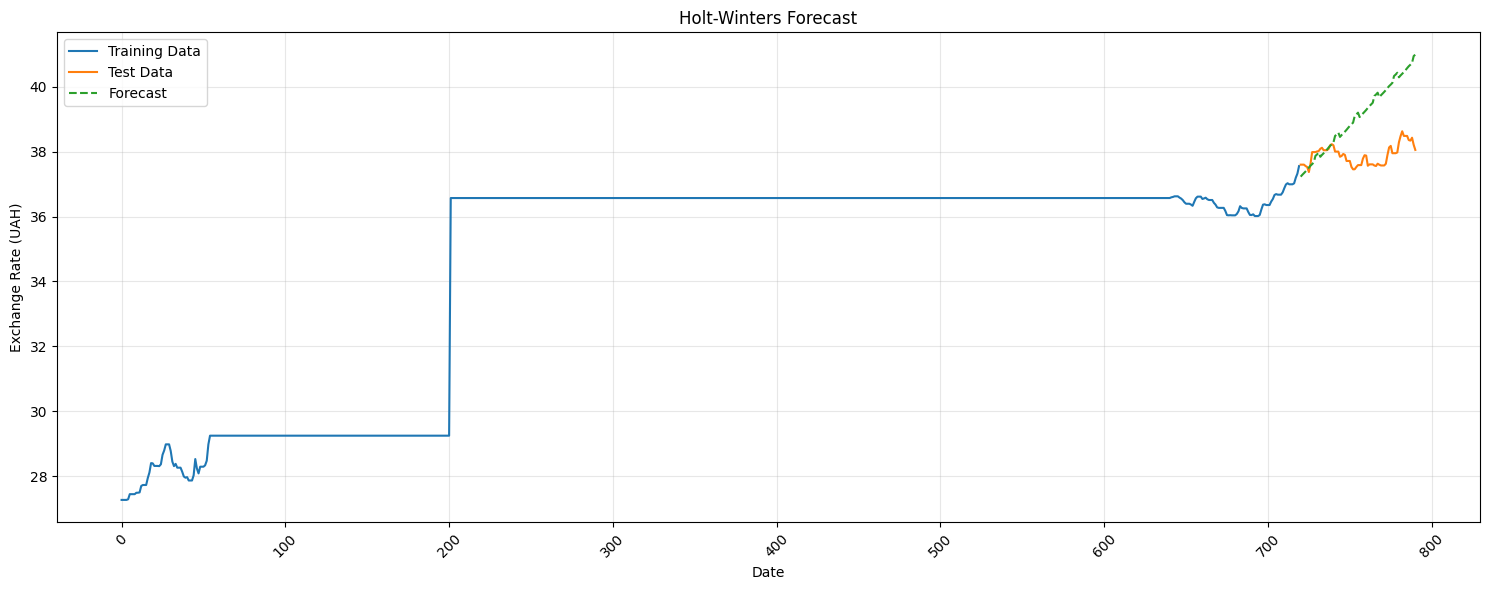

ValueError: Actual and predicted arrays must have the same length

In [24]:

def exponential_smoothing_forecast(data, alpha):
    forecast = np.zeros(len(data))
    forecast[0] = data[0]
    for i in range(1, len(data)):
        forecast[i] = alpha * data[i] + (1 - alpha) * forecast[i-1]
    return forecast

def holt_winters_forecast(data, alpha=0.2, beta=0.1, gamma=0.3, seasonal_periods=12, forecast_periods=12):
    n = len(data)
    
    level = np.zeros(n)
    trend = np.zeros(n)
    seasonal = np.zeros(n)
    
    level[0] = data[0]
    trend[0] = data[1] - data[0]
    
    season_averages = []
    for i in range(seasonal_periods):
        season_averages.append(np.mean(data[i::seasonal_periods]))
    global_average = np.mean(season_averages)
    initial_seasonal = [sa / global_average for sa in season_averages]
    
    for i in range(seasonal_periods):
        seasonal[i] = initial_seasonal[i]
    
    for i in range(1, n):
        if i >= seasonal_periods:
            level[i] = alpha * (data[i] / seasonal[i - seasonal_periods]) + \
                      (1 - alpha) * (level[i-1] + trend[i-1])
            trend[i] = beta * (level[i] - level[i-1]) + (1 - beta) * trend[i-1]
            seasonal[i] = gamma * (data[i] / level[i]) + \
                         (1 - gamma) * seasonal[i - seasonal_periods]
        else:
            level[i] = alpha * data[i] + (1 - alpha) * (level[i-1] + trend[i-1])
            trend[i] = beta * (level[i] - level[i-1]) + (1 - beta) * trend[i-1]
            seasonal[i] = seasonal[i]
    
    forecast = np.zeros(n + forecast_periods)
    forecast[:n] = data
    
    for i in range(n, n + forecast_periods):
        season_idx = (i % seasonal_periods)
        forecast[i] = (level[-1] + trend[-1] * (i - n + 1)) * \
                     seasonal[season_idx]
    
    return forecast

def plot_forecast(train, test, forecast, title="Holt-Winters Forecast"):
    plt.figure(figsize=(15, 6))
    plt.plot(train.index, train['Офіційний курс гривні, грн'], label='Training Data')
    plt.plot(test.index, test['Офіційний курс гривні, грн'], label='Test Data')
    plt.plot(test.index, forecast[len(train):], label='Forecast', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Exchange Rate (UAH)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

train_len = 720
train = _data.iloc[:train_len].copy()
test = _data.iloc[train_len:].copy()

train_data = train['Офіційний курс гривні, грн'].values
test_data = test['Офіційний курс гривні, грн'].values

forecast = holt_winters_forecast(
    train_data,
    alpha=0.2,
    beta=0.1,
    gamma=0.3,
    seasonal_periods=12,
    forecast_periods=len(test_data)
)

plot_forecast(train, test, forecast)

errors = calculate_errors(test_data, forecast)
print("\nForecast Error Metrics:")
print(f"RMSE: {errors['RMSE']:.4f}")
print(f"MAE: {errors['MAE']:.4f}")

ModuleNotFoundError: No module named 'statsmodels'